In [ ]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import STAGATE
import GraphST
import SpaGCN

section = "151509"

adata = sc.read_h5ad(
    f"data/DLPFC_{section}_ST_final.h5ad"
)

coords = np.asarray(adata.obsm["spatial"])
n_spots = adata.n_obs

print("Section:", section)
print("Spots:", n_spots)

In [2]:
# ============================================================
# STAGATE k=3
# ============================================================

adata_st = adata.copy()

STAGATE.Cal_Spatial_Net(
    adata_st,
    k_cutoff=3,
    model="KNN",
    verbose=False
)

stagate_net = adata_st.uns["Spatial_Net"]

cell_to_idx = {
    cell: i
    for i, cell in enumerate(adata.obs_names)
}

stagate_neighbors = {
    i: set()
    for i in range(n_spots)
}

for _, row in stagate_net.iterrows():

    i = cell_to_idx[row["Cell1"]]
    j = cell_to_idx[row["Cell2"]]

    stagate_neighbors[i].add(j)

print(
    "STAGATE average degree:",
    np.mean([
        len(x)
        for x in stagate_neighbors.values()
    ])
)

STAGATE average degree: 3.0


In [3]:
# ============================================================
# GraphST k=3
# ============================================================

adata_gs = adata.copy()

GraphST.construct_interaction(
    adata_gs,
    n_neighbors=3
)

graphst_adj = np.asarray(
    adata_gs.obsm["adj"]
)

graphst_neighbors = {
    i: set(
        np.where(graphst_adj[i] > 0)[0]
    )
    for i in range(n_spots)
}

print(
    "GraphST average degree:",
    np.mean([
        len(x)
        for x in graphst_neighbors.values()
    ])
)

GraphST average degree: 3.4414038019636517


In [4]:
# ============================================================
# SpaGCN
# ============================================================

x = coords[:, 0].tolist()
y = coords[:, 1].tolist()

spagcn_dist = SpaGCN.calculate_adj_matrix(
    x=x,
    y=y,
    histology=False
)

spagcn_l = SpaGCN.search_l(
    0.5,
    spagcn_dist
)

spagcn_weights = np.exp(
    -(
        spagcn_dist ** 2
    ) / (
        2 * spagcn_l ** 2
    )
)

np.fill_diagonal(
    spagcn_weights,
    0
)

# Top 3 neighbors
spagcn_neighbors = {}

for i in range(n_spots):

    row = spagcn_weights[i].copy()

    top3 = np.argpartition(
        row,
        -3
    )[-3:]

    top3 = top3[
        np.argsort(
            row[top3]
        )[::-1]
    ]

    spagcn_neighbors[i] = set(
        top3.tolist()
    )

print(
    "SpaGCN average degree:",
    np.mean([
        len(x)
        for x in spagcn_neighbors.values()
    ])
)

Calculateing adj matrix using xy only...
Run 1: l [0.01, 1000], p [0.0, 311.3569]
Run 2: l [0.01, 500.005], p [0.0, 84.6404]
Run 3: l [0.01, 250.0075], p [0.0, 21.384966]
Run 4: l [0.01, 125.00874999999999], p [0.0, 4.724241]
recommended l =  62.509375
SpaGCN average degree: 3.0


In [5]:
def calculate_spot_jaccard(
    neighbors_a,
    neighbors_b,
    n_spots
):

    scores = np.zeros(n_spots)

    for i in range(n_spots):

        A = neighbors_a[i]
        B = neighbors_b[i]

        union = A | B

        if len(union) == 0:
            scores[i] = np.nan
        else:
            scores[i] = len(A & B) / len(union)

    return scores

In [6]:
j_st_gs = calculate_spot_jaccard(
    stagate_neighbors,
    graphst_neighbors,
    n_spots
)

j_st_sp = calculate_spot_jaccard(
    stagate_neighbors,
    spagcn_neighbors,
    n_spots
)

j_gs_sp = calculate_spot_jaccard(
    graphst_neighbors,
    spagcn_neighbors,
    n_spots
)

In [7]:
adata.obs["jaccard_STAGATE_GraphST"] = j_st_gs
adata.obs["jaccard_STAGATE_SpaGCN"] = j_st_sp
adata.obs["jaccard_GraphST_SpaGCN"] = j_gs_sp

In [8]:
print(
    adata.obs[
        [
            "jaccard_STAGATE_GraphST",
            "jaccard_STAGATE_SpaGCN",
            "jaccard_GraphST_SpaGCN"
        ]
    ].describe()
)

       jaccard_STAGATE_GraphST  jaccard_STAGATE_SpaGCN  jaccard_GraphST_SpaGCN
count              4787.000000             4787.000000             4787.000000
mean                  0.796073                0.839461                0.793608
std                   0.193706                0.233470                0.195458
min                   0.400000                0.500000                0.400000
25%                   0.750000                0.500000                0.750000
50%                   0.750000                1.000000                0.750000
75%                   1.000000                1.000000                1.000000
max                   1.000000                1.000000                1.000000


In [9]:
worst = (
    adata.obs[
        "jaccard_STAGATE_GraphST"
    ]
    .sort_values()
)

print(worst.head(30))

worst_indices = (
    adata.obs[
        "jaccard_STAGATE_GraphST"
    ]
    .nsmallest(30)
    .index
)

print(worst_indices)
for idx in worst_indices[:10]:

    i = adata.obs_names.get_loc(idx)

    print("\nSpot:", idx)

    print(
        "STAGATE:",
        sorted(stagate_neighbors[i])
    )

    print(
        "GraphST:",
        sorted(graphst_neighbors[i])
    )

    print(
        "SpaGCN:",
        sorted(spagcn_neighbors[i])
    )

    print(
        "Jaccard STAGATE/GraphST:",
        j_st_gs[i]
    )

CTAACTGATAATCGCC-1_151509    0.4
TGGTAGAATATATGGG-1_151509    0.4
GCGCTATGCCGAGGCA-1_151509    0.4
GCGAAACTTAACTGGA-1_151509    0.4
GCCTCTATACATAGCA-1_151509    0.4
GCCGCACTCCGTTTCA-1_151509    0.4
AATGACGTAGGATGTC-1_151509    0.4
GCATAGAGCACTCAGG-1_151509    0.4
CCCGCCATGCTCCCGT-1_151509    0.4
TGTGAGACTAGCCCAA-1_151509    0.4
CCCTGGGAGGGATCCT-1_151509    0.4
CCCTTCTCGTACGCGA-1_151509    0.4
GATGACGATGATCGCG-1_151509    0.4
CCGCTCCAGGGCGATC-1_151509    0.4
AAGGTATCCTAATATA-1_151509    0.4
TTAGAAGAACATGACT-1_151509    0.4
GAGTATACCCTAATCA-1_151509    0.4
CCTATACCGTCCTGTC-1_151509    0.4
CCTATGGCTCCTAGTG-1_151509    0.4
TTCAGCCCTGGTCCAC-1_151509    0.4
AAGAAGGATCAGTTAG-1_151509    0.4
GACGGGCATCGAATTT-1_151509    0.4
CCTTTGAATTATGGCT-1_151509    0.4
CGAACAGTATGGGCGT-1_151509    0.4
CGAGATGTTGCCTATA-1_151509    0.4
CGCCCTTGAAGGCTGA-1_151509    0.4
TTCTTGCTAGCATCTC-1_151509    0.4
CTTAAGCAGCGAGCCG-1_151509    0.4
TGGCCGTATATTGACC-1_151509    0.4
TTGATGTGTAGTCCCG-1_151509    0.4
Name: jacc

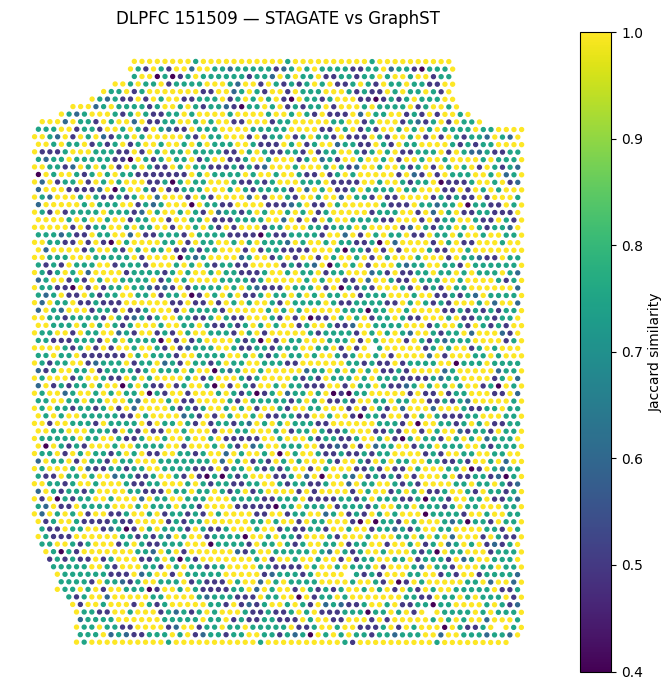

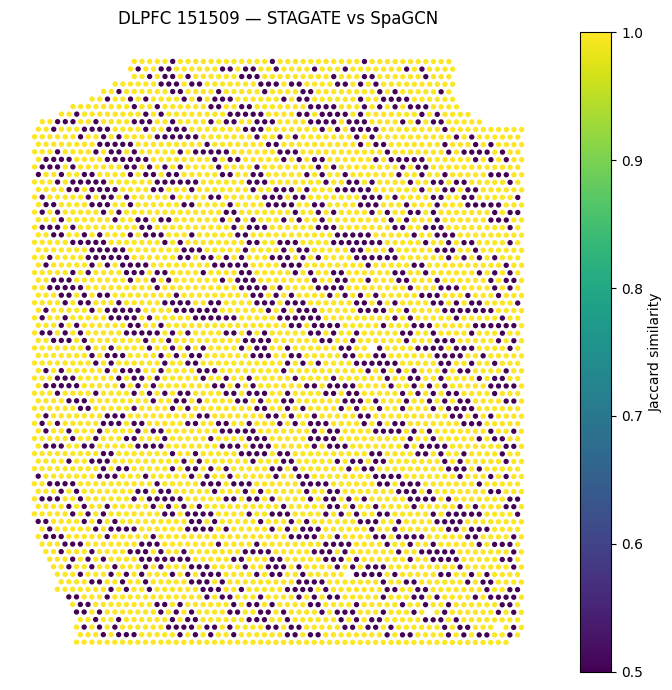

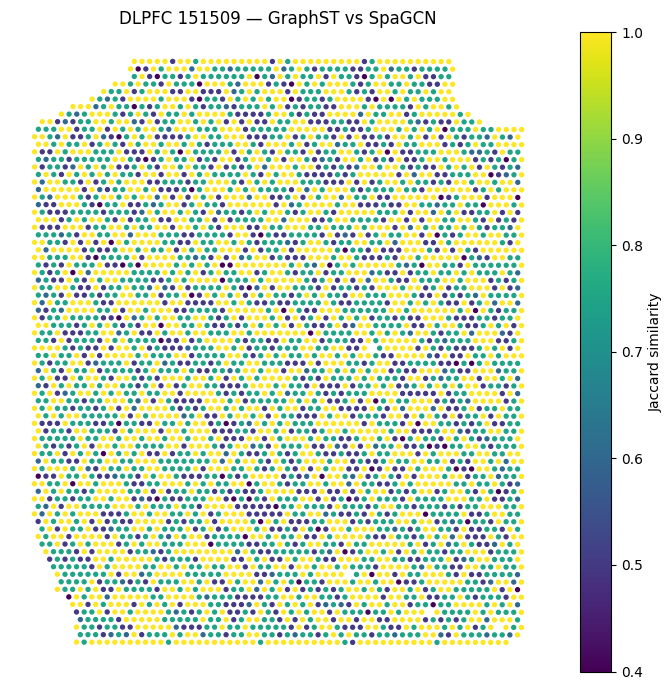

In [10]:
def plot_jaccard(
    adata,
    values,
    title,
    filename=None
):

    coords = np.asarray(
        adata.obsm["spatial"]
    )

    fig, ax = plt.subplots(
        figsize=(7, 7)
    )

    scatter = ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c=values,
        s=8
    )

    ax.invert_yaxis()

    ax.set_title(title)

    ax.axis("off")

    cbar = plt.colorbar(
        scatter,
        ax=ax
    )

    cbar.set_label(
        "Jaccard similarity"
    )

    plt.tight_layout()

    if filename:
        plt.savefig(
            filename,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

plot_jaccard(
    adata,
    j_st_gs,
    "DLPFC 151509 — STAGATE vs GraphST",
    "151509_stagate_graphst_jaccard.png"
)

plot_jaccard(
    adata,
    j_st_sp,
    "DLPFC 151509 — STAGATE vs SpaGCN",
    "151509_stagate_spagcn_jaccard.png"
)

plot_jaccard(
    adata,
    j_gs_sp,
    "DLPFC 151509 — GraphST vs SpaGCN",
    "151509_graphst_spagcn_jaccard.png"
)

In [11]:
investigation = pd.DataFrame({
    "spot": adata.obs_names,
    "STAGATE_GraphST": j_st_gs,
    "STAGATE_SpaGCN": j_st_sp,
    "GraphST_SpaGCN": j_gs_sp,
    "x": coords[:, 0],
    "y": coords[:, 1]
})

investigation["mean_jaccard"] = investigation[
    [
        "STAGATE_GraphST",
        "STAGATE_SpaGCN",
        "GraphST_SpaGCN"
    ]
].mean(axis=1)

investigation = investigation.sort_values(
    "mean_jaccard"
)

print(
    investigation.head(30).to_string(
        index=False
    )
)

                     spot  STAGATE_GraphST  STAGATE_SpaGCN  GraphST_SpaGCN     x     y  mean_jaccard
CTCATTCGTGAACATC-1_151509              0.5             0.5             0.5  2398  5864           0.5
CCGATTCGAGGGACCC-1_151509              0.5             0.5             0.5  3578  7194           0.5
AGAGAACCGTCTAGGA-1_151509              0.5             0.5             0.5  8302  5747           0.5
GTCATGGACATGACTA-1_151509              0.5             0.5             0.5  6496  5746           0.5
CAGCCTCTCCTCAAGA-1_151509              0.5             0.5             0.5  8789  4418           0.5
GTCATTGCATTGACCC-1_151509              0.5             0.5             0.5  3370  6348           0.5
CAGCGCCAACACGATA-1_151509              0.5             0.5             0.5  2536  7073           0.5
CGCTGTGTGGATGTTG-1_151509              0.5             0.5             0.5  5174  9733           0.5
TCGAGACCAACACCGT-1_151509              0.5             0.5             0.5  6009  7075     

### Check whether disagreement is simply caused by boundary spots

In [12]:
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(
    n_neighbors=4
).fit(coords)

distances, indices = nbrs.kneighbors(
    coords
)

# distance[:, 0] is distance to itself
third_neighbor_distance = distances[:, 3]

investigation["third_neighbor_distance"] = \
    third_neighbor_distance

print(
    investigation[
        [
            "mean_jaccard",
            "third_neighbor_distance"
        ]
    ].corr()
)

                         mean_jaccard  third_neighbor_distance
mean_jaccard                 1.000000                 0.003462
third_neighbor_distance      0.003462                 1.000000


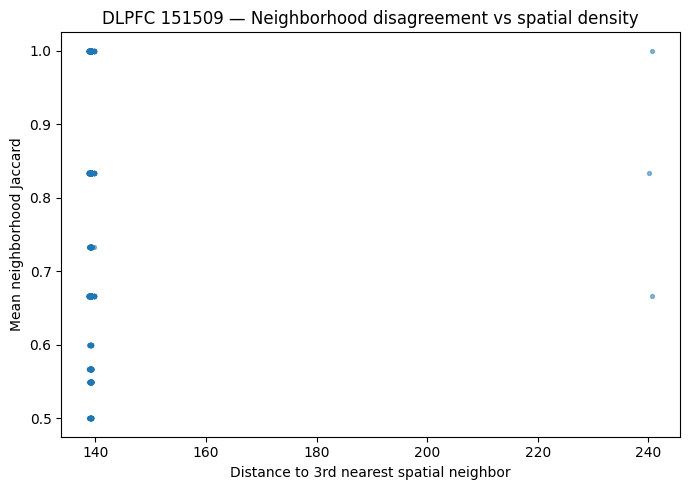

In [13]:
plt.figure(figsize=(7, 5))

plt.scatter(
    investigation["third_neighbor_distance"],
    investigation["mean_jaccard"],
    s=8,
    alpha=0.5
)

plt.xlabel(
    "Distance to 3rd nearest spatial neighbor"
)

plt.ylabel(
    "Mean neighborhood Jaccard"
)

plt.title(
    "DLPFC 151509 — Neighborhood disagreement vs spatial density"
)

plt.tight_layout()

plt.savefig(
    "151509_jaccard_vs_spatial_density.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
from sklearn.metrics import pairwise_distances

D = pairwise_distances(coords)

tie_info = []

for i in range(n_spots):

    row = D[i].copy()

    # remove self
    row[i] = np.inf

    sorted_distances = np.sort(row)

    d3 = sorted_distances[2]

    # How many spots have exactly this distance?
    n_at_d3 = np.sum(
        np.isclose(row, d3)
    )

    # How many spots are at or closer than d3?
    n_within_d3 = np.sum(
        row <= d3 + 1e-8
    )

    tie_info.append({
        "spot": i,
        "d3": d3,
        "n_at_d3": n_at_d3,
        "n_within_d3": n_within_d3
    })

tie_df = pd.DataFrame(tie_info)

print(tie_df["n_at_d3"].value_counts().sort_index())

n_at_d3
1    1085
2    3232
3     470
Name: count, dtype: int64


In [15]:
print(
    np.unique(
        np.round(
            tie_df["d3"],
            3
        ),
        return_counts=True
    )
)

(array([138.924, 139.   , 139.004, 139.291, 139.789, 240.133, 240.635]), array([ 152, 1535,    6, 3046,   45,    1,    2]))


In [17]:
tie_analysis = []

for i in range(n_spots):

    row = D[i].copy()
    row[i] = np.inf

    sorted_distances = np.sort(row)

    d3 = sorted_distances[2]

    # Number strictly closer than d3
    n_strictly_closer = np.sum(
        row < d3 - 1e-8
    )

    # Number exactly at d3
    n_at_d3 = np.sum(
        np.isclose(row, d3)
    )

    # Number of neighbors we still need to select
    needed = 3 - n_strictly_closer

    # A tie is actually problematic if:
    # there are more candidates at d3 than we need
    ambiguous = (
        n_at_d3 > needed
    )

    tie_analysis.append({
        "spot": i,
        "d3": d3,
        "n_strictly_closer": n_strictly_closer,
        "n_at_d3": n_at_d3,
        "needed_from_tie": needed,
        "ambiguous": ambiguous
    })

tie_df = pd.DataFrame(tie_analysis)

print(
    tie_df["ambiguous"].value_counts()
)

print(
    "\nPercentage ambiguous:",
    tie_df["ambiguous"].mean() * 100
)

ambiguous
True     2963
False    1824
Name: count, dtype: int64

Percentage ambiguous: 61.89680384374348


In [18]:
print("adata.n_obs:", adata.n_obs)
print("coords.shape:", coords.shape)
print("D.shape:", D.shape)

print(tie_df.shape)

print(tie_df["ambiguous"].value_counts())

adata.n_obs: 4787
coords.shape: (4787, 2)
D.shape: (4787, 4787)
(4787, 6)
ambiguous
True     2963
False    1824
Name: count, dtype: int64


In [19]:
# Compare Jaccard for ambiguous vs unambiguous spots

ambiguous_mask = tie_df["ambiguous"].values
unambiguous_mask = ~ambiguous_mask

print("Ambiguous spots:", ambiguous_mask.sum())
print("Unambiguous spots:", unambiguous_mask.sum())

print("\nSTAGATE vs GraphST")
print(
    "Ambiguous:",
    j_st_gs[ambiguous_mask].mean()
)
print(
    "Unambiguous:",
    j_st_gs[unambiguous_mask].mean()
)

print("\nSTAGATE vs SpaGCN")
print(
    "Ambiguous:",
    j_st_sp[ambiguous_mask].mean()
)
print(
    "Unambiguous:",
    j_st_sp[unambiguous_mask].mean()
)

print("\nGraphST vs SpaGCN")
print(
    "Ambiguous:",
    j_gs_sp[ambiguous_mask].mean()
)
print(
    "Unambiguous:",
    j_gs_sp[unambiguous_mask].mean()
)

Ambiguous spots: 2963
Unambiguous spots: 1824

STAGATE vs GraphST
Ambiguous: 0.7305771177860277
Unambiguous: 0.9024671052631579

STAGATE vs SpaGCN
Ambiguous: 0.7406344920688491
Unambiguous: 1.0

GraphST vs SpaGCN
Ambiguous: 0.7265946675666553
Unambiguous: 0.9024671052631579


The comparatively lower neighborhood similarity observed for section 151509 was investigated at the individual-spot level. The section exhibited substantial spatial-distance degeneracy: 2,963 of 4,787 spots (61.9%) had an ambiguous third-neighbor cutoff. When only unambiguous spots were considered, STAGATE and coordinate-only SpaGCN exhibited complete neighborhood agreement (Jaccard = 1.00), while GraphST showed a high agreement of 0.90 with both methods. This indicates that much of the apparent disagreement between the spatial graphs originates from the selection of individual neighbors among spots with equivalent spatial distances rather than fundamentally different spatial neighborhood structures.